In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import torch

In [2]:
df = pd.read_csv("msd03_ablation.csv", index_col=0)

In [3]:
df

,obj_id,vol_avg_dice,global_allres_sim,global_lowres_sim,global_masked_allres_sim,global_masked_lowres_sim,local_allres_sim,local_lowres_sim,local_masked_allres_sim,local_masked_lowres_sim
0,liver_92.nii.gz_1,tensor(0.5722),"[172, 0]","[172, 0]","[161, 11]","[151, 21]","[172, 0]","[172, 0]","[168, 4]","[171, 1]"
1,liver_92.nii.gz_2,tensor(0.0011),"[36, 2]","[37, 1]","[3, 35]","[14, 24]","[38, 0]","[38, 0]","[31, 7]","[35, 3]"
2,liver_60.nii.gz_1,tensor(0.7809),"[71, 1]","[61, 11]","[62, 10]","[51, 21]","[72, 0]","[72, 0]","[65, 7]","[67, 5]"
3,liver_60.nii.gz_2,tensor(0.5373),"[11, 0]","[11, 0]","[6, 5]","[5, 6]","[11, 0]","[11, 0]","[7, 4]","[7, 4]"
4,liver_34.nii.gz_1,tensor(0.4650),"[91, 0]","[85, 6]","[86, 5]","[79, 12]","[91, 0]","[91, 0]","[91, 0]","[88, 3]"
...,...,...,...,...,...,...,...,...,...,...
244,liver_1.nii.gz_2,tensor(0.0424),"[11, 0]","[11, 0]","[1, 10]","[1, 10]","[11, 0]","[11, 0]","[8, 3]","[9, 2]"
245,liver_13.nii.gz_1,tensor(0.),"[135, 0]","[132, 3]","[96, 39]","[96, 39]","[135, 0]","[135, 0]","[133, 2]","[131, 4]"
246,liver_13.nii.gz_2,tensor(0.),"[56, 0]","[55, 1]","[15, 41]","[16, 40]","[56, 0]","[56, 0]","[40, 16]","[44, 12]"
247,liver_37.nii.gz_1,tensor(0.6558),"[92, 0]","[90, 2]","[83, 9]","[72, 20]","[92, 0]","[92, 0]","[82, 10]","[84, 8]"


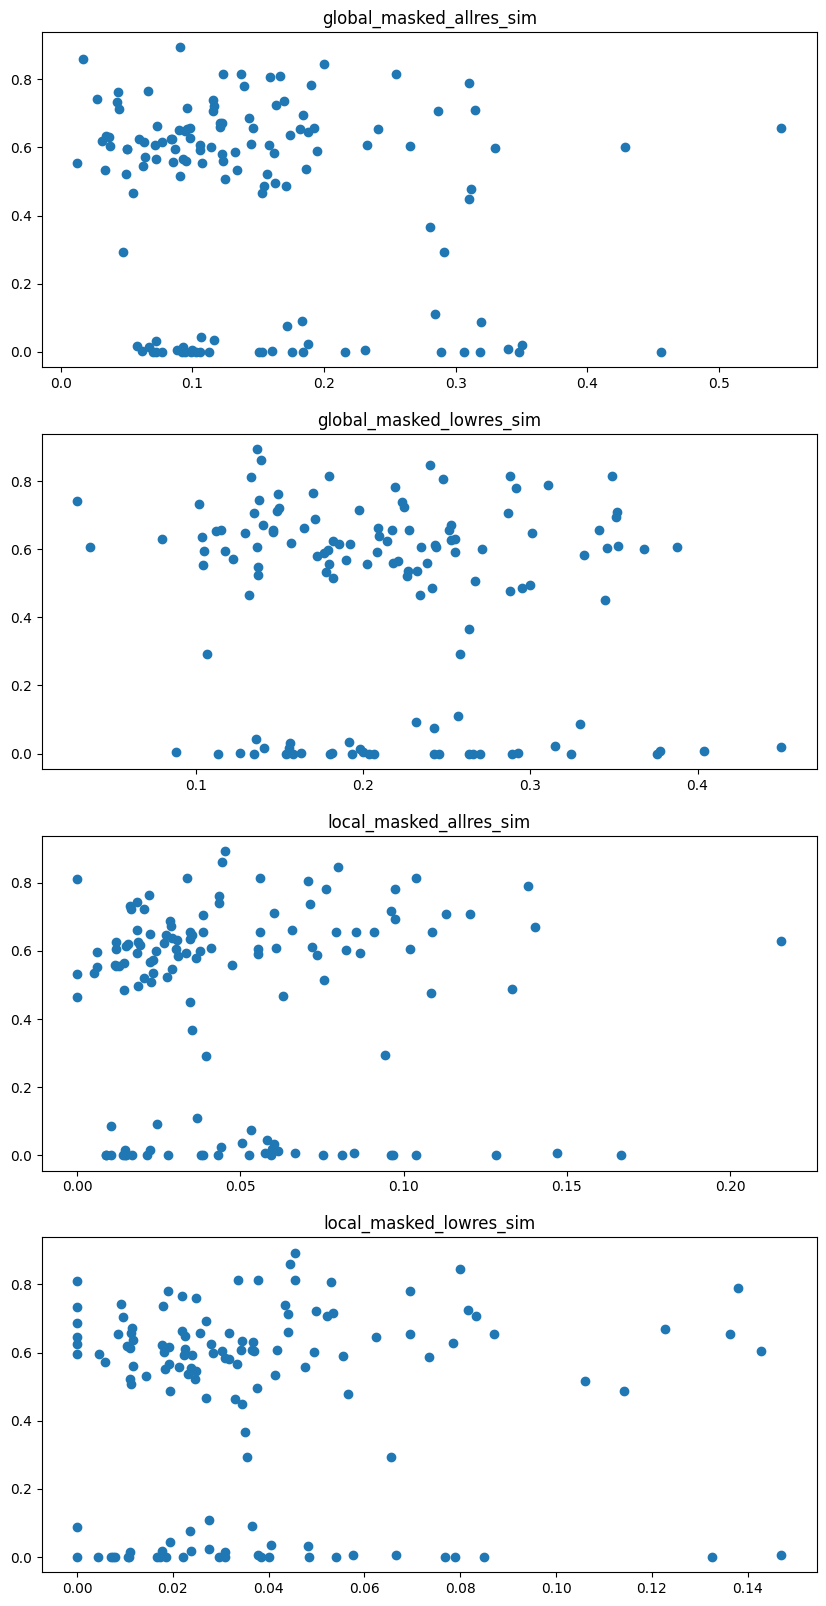

In [11]:
metrics = df.columns[df.columns.str.contains("mask")]
fig, axes = plt.subplots(nrows=len(metrics), figsize=(10,20))
for idx, metric in enumerate(metrics):
    point_1 = []
    point_2 = []
     
    for i in range(len(df)):
        obj_id = int(df.loc[i, "obj_id"][-1])
        dice = eval("torch." + df.loc[i, "vol_avg_dice"]).item()
        num = eval(df.loc[i, metric])
        rate = num[1] / (num[0] + num[1] + 1e-8)
        
        if obj_id == 1:
            point_1.append((dice, rate))
        elif obj_id == 2:
            point_2.append((dice, rate))
    
    dice_y, rate_x = zip(*point_1)
    
    axes[idx].set_title(metric)
    axes[idx].scatter(x=rate_x, y=dice_y)
    
    # dice_y, rate_x = zip(*point_2)
    # axes[idx].scatter(x=rate_x, y=dice_y)
    
    # axes[idx].legend(loc='lower right')